# Purpose
This notebook conducts sensitive analysis of network density and generates Fig S29-S32 (Supplementary Note 2).

In [1]:
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import sys
sys.path.append("..")
from scripts import stats_analysis, draw

In [2]:
cond_ls = ['A', 'C'] # Weight adjustment condition
tau_ls = [0.05, 0.1, 0.5] # tau_reweight
density_ls = [0.01, 0.05, 0.2, 0.3] # Network density
eta = 10.0 # learning rate

r2_thresh = 0.85 # threshold of r2 for the power-law fit

In [3]:
A_wAdjAlone = {}; A_wAdjRand = {}; A_dualAdapt = {}
for cond in cond_ls:
    A_wAdjAlone[cond] = {}; A_wAdjRand[cond] = {}; A_dualAdapt[cond] = {}
    for tau in tau_ls:
        A_wAdjAlone[cond][tau] = {}; A_wAdjRand[cond][tau] = {}; A_dualAdapt[cond][tau] = {}
        for density in density_ls:    
            f = open('./Output/change network density/wAdjust_alone_'+cond+'_eta_'+str(eta)+'_tau_'+str(tau)+'_'+str(density)+'.pckl', 'rb')
            A_wAdjAlone[cond][tau][density], _ = pickle.load(f)
            f.close()
            
            f = open('./Output/change network density/wAdjust_randRew_'+cond+'_eta_'+str(eta)+'_tau_'+str(tau)+'_'+str(density)+'.pckl', 'rb')
            A_wAdjRand[cond][tau][density], _ = pickle.load(f)
            f.close()
            
            f = open('./Output/change network density/dualAdapt_'+cond+'_eta_'+str(eta)+'_tau_'+str(tau)+'_'+str(density)+'.pckl', 'rb')
            A_dualAdapt[cond][tau][density], _ = pickle.load(f)
            f.close()

# Fig S29: Density = 0.05

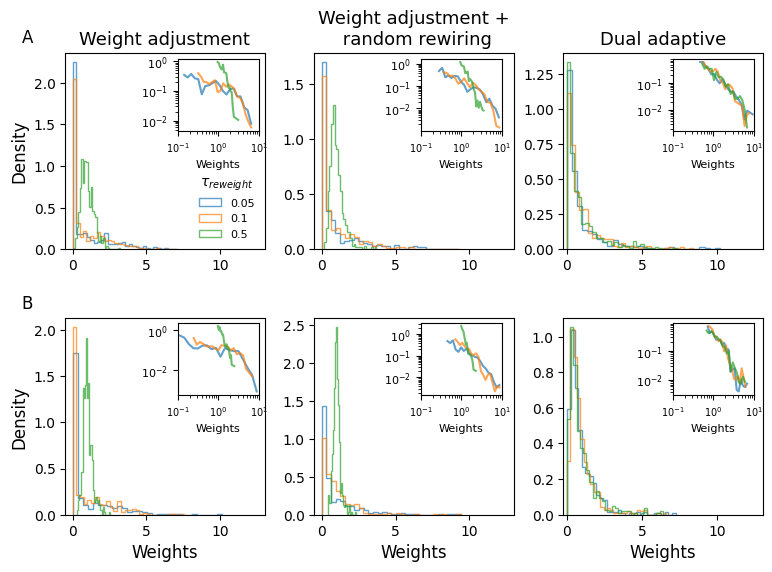

In [4]:
density = 0.05
num_bins = 20 # number of bins on the logscale for the histogram of the upper tail of the weight distribution

plt.rcParams["figure.figsize"] = (9, 6)
fig, ax1 = plt.subplots(2, 3)
for i, cond in enumerate(cond_ls):
    # Adaptive weight adjustment with fixed connectivity
    # weight distribution
    for l, tau in enumerate(tau_ls):
        weights = A_wAdjAlone[cond][tau][density][A_wAdjAlone[cond][tau][density]>0]
        ax1[i, 0].hist(weights, bins=30, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
        ax1[i, 0].tick_params(axis = 'both', labelsize=10)
        ax1[i, 0].set_xlim([-0.5, 13])        
    # right tails in log-log scale
    left, bottom, width, height = [0.25, 0.75-i*0.44, 0.09, 0.12]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    slope = []
    for l, tau in enumerate(tau_ls):
        res = stats_analysis.PL_MLE(A_wAdjAlone[cond][tau][density], num_bins)    
        if res[2] > r2_thresh:
            slope.append(-res[1])
        else:
            slope.append(np.nan)
        weights = A_wAdjAlone[cond][tau][density][A_wAdjAlone[cond][tau][density]>0]
        draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
    ax1_1.set_xlabel('Weights',fontsize=8)
    ax1_1.tick_params(axis = 'both', labelsize=8)
    ax1_1.set_xlim([0.1, 10]) 
    ax1_1.set_xscale('log')
    ax1_1.set_yscale('log')
    ax1_1.xaxis.set_major_locator(LogLocator(base=10, numticks=3))
    ax1_1.xaxis.set_minor_formatter(NullFormatter())
    ax1_1.tick_params(axis='x', labelsize=7)

    # Adaptive weight adjustment with random rewiring
    # weight distribution
    for l, tau in enumerate(tau_ls):
        weights = A_wAdjRand[cond][tau][density][A_wAdjRand[cond][tau][density]>0]
        ax1[i, 1].hist(weights, bins=30, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
        ax1[i, 1].tick_params(axis = 'both', labelsize=10)
        ax1[i, 1].set_xlim([-0.5, 13])
    # right tails in log-log scale
    left, bottom, width, height = [0.52, 0.75-i*0.44, 0.09, 0.12]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    slope = []
    for l, tau in enumerate(tau_ls):
        res = stats_analysis.PL_MLE(A_wAdjRand[cond][tau][density], num_bins) 
        if res[2] > r2_thresh:
            slope.append(-res[1])
        else:
            slope.append(np.nan)
        weights = A_wAdjRand[cond][tau][density][A_wAdjRand[cond][tau][density]>0]
        draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
    ax1_1.set_xlabel('Weights',fontsize=8)
    ax1_1.tick_params(axis = 'both', labelsize=8)
    ax1_1.set_xlim([0.1, 10]) 
    ax1_1.set_xscale('log')
    ax1_1.set_yscale('log')
    ax1_1.xaxis.set_major_locator(LogLocator(base=10, numticks=3))
    ax1_1.xaxis.set_minor_formatter(NullFormatter())
    ax1_1.tick_params(axis='x', labelsize=7)

    # Adaptive weight adjustment with adaptive rewiring
    # weight distribution
    for l, tau in enumerate(tau_ls):
        weights = A_dualAdapt[cond][tau][density][A_dualAdapt[cond][tau][density]>0]
        ax1[i, 2].hist(weights, bins=30, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
        ax1[i, 2].tick_params(axis = 'both', labelsize=10)
        ax1[i, 2].set_xlim([-0.2, 13])                
    # right tails in log-log scale
    left, bottom, width, height = [0.80, 0.75-i*0.44, 0.09, 0.12]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    slope = []
    for l, tau in enumerate(tau_ls):
        res = stats_analysis.PL_MLE(A_dualAdapt[cond][tau][density], num_bins) 
        if res[2] > r2_thresh:
            slope.append(-res[1])
        else:
            slope.append(np.nan)
        weights = A_dualAdapt[cond][tau][density][A_dualAdapt[cond][tau][density]>0]
        draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
    ax1_1.set_xlabel('Weights',fontsize=8)
    ax1_1.tick_params(axis = 'both', labelsize=8)
    ax1_1.set_xlim([0.1, 10]) 
    ax1_1.set_xscale('log')
    ax1_1.set_yscale('log')
    ax1_1.xaxis.set_major_locator(LogLocator(base=10, numticks=3))
    ax1_1.xaxis.set_minor_formatter(NullFormatter())
    ax1_1.tick_params(axis='x', labelsize=7)
    
    ax1[i, 0].set_ylabel('Density',fontsize=12)

ax1[0, 0].legend(title = '$\\tau_{reweight}$', frameon=False, loc='lower right', fontsize=8)
ax1[0, 0].set_title('Weight adjustment', fontsize=13)
ax1[0, 1].set_title('Weight adjustment +\n random rewiring', fontsize=13)
ax1[0, 2].set_title('Dual adaptive', fontsize=13)
for s in range(3):
    ax1[1, s].set_xlabel( 'Weights', size=12)
ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
fig.subplots_adjust(hspace = 0.35, wspace = 0.25)
#plt.savefig('../fig/Fig S29.svg', dpi = 300)

# Fig S30: Density = 0.2

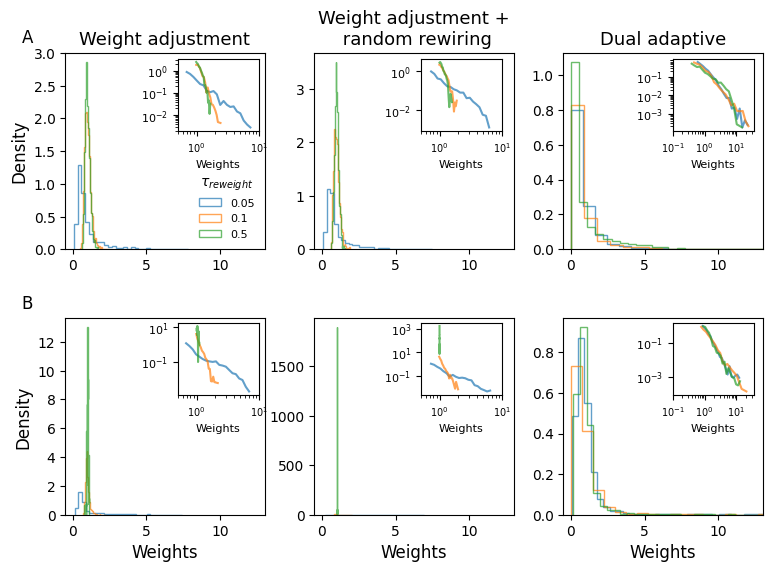

In [5]:
density = 0.2
num_bins = 20 # number of bins on the logscale for the histogram of the upper tail of the weight distribution

plt.rcParams["figure.figsize"] = (9, 6)
fig, ax1 = plt.subplots(2, 3)
for i, cond in enumerate(cond_ls):
    # Adaptive weight adjustment with fixed connectivity
    # weight distribution
    for l, tau in enumerate(tau_ls):
        weights = A_wAdjAlone[cond][tau][density][A_wAdjAlone[cond][tau][density]>0]
        ax1[i, 0].hist(weights, bins=30, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
        ax1[i, 0].tick_params(axis = 'both', labelsize=10)
        ax1[i, 0].set_xlim([-0.5, 13])        
    # right tails in log-log scale
    left, bottom, width, height = [0.25, 0.75-i*0.44, 0.09, 0.12]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    slope = []
    for l, tau in enumerate(tau_ls):
        res = stats_analysis.PL_MLE(A_wAdjAlone[cond][tau][density], num_bins)    
        
        if res[2] > r2_thresh:
            slope.append(-res[1])
        else:
            slope.append(np.nan)
        weights = A_wAdjAlone[cond][tau][density][A_wAdjAlone[cond][tau][density]>0]
        draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
    ax1_1.set_xlabel('Weights',fontsize=8)
    ax1_1.tick_params(axis = 'both', labelsize=8)
    ax1_1.set_xlim([0.5, 10]) 
    ax1_1.set_xscale('log')
    ax1_1.set_yscale('log')
    ax1_1.xaxis.set_major_locator(LogLocator(base=10, numticks=3))
    ax1_1.xaxis.set_minor_formatter(NullFormatter())
    ax1_1.tick_params(axis='x', labelsize=7)
    
    # Adaptive weight adjustment with random rewiring
    # weight distribution
    for l, tau in enumerate(tau_ls):
        weights = A_wAdjRand[cond][tau][density][A_wAdjRand[cond][tau][density]>0]
        ax1[i, 1].hist(weights, bins=30, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
        ax1[i, 1].tick_params(axis = 'both', labelsize=10)
        ax1[i, 1].set_xlim([-0.5, 13])
    # right tails in log-log scale           
    left, bottom, width, height = [0.52, 0.75-i*0.44, 0.09, 0.12]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    slope = []
    for l, tau in enumerate(tau_ls):
        res = stats_analysis.PL_MLE(A_wAdjRand[cond][tau][density], num_bins) 
        if res[2] > r2_thresh:
            slope.append(-res[1])
        else:
            slope.append(np.nan)
        weights = A_wAdjRand[cond][tau][density][A_wAdjRand[cond][tau][density]>0]
        draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
    ax1_1.set_xlabel('Weights',fontsize=8)
    ax1_1.tick_params(axis = 'both', labelsize=8)
    ax1_1.set_xlim([0.5, 10]) 
    ax1_1.set_xscale('log')
    ax1_1.set_yscale('log')
    ax1_1.xaxis.set_major_locator(LogLocator(base=10, numticks=3))
    ax1_1.xaxis.set_minor_formatter(NullFormatter())
    ax1_1.tick_params(axis='x', labelsize=7)
    
    # Adaptive weight adjustment with adaptive rewiring
    # weight distribution
    for l, tau in enumerate(tau_ls):
        weights = A_dualAdapt[cond][tau][density][A_dualAdapt[cond][tau][density]>0]
        ax1[i, 2].hist(weights, bins=30, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
        ax1[i, 2].tick_params(axis = 'both', labelsize=10)
        ax1[i, 2].set_xlim([-0.5, 13])                
    # right tails in log-log scale           
    left, bottom, width, height = [0.80, 0.75-i*0.44, 0.09, 0.12]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    slope = []
    for l, tau in enumerate(tau_ls):
        res = stats_analysis.PL_MLE(A_dualAdapt[cond][tau][density], num_bins) 
        if res[2] > r2_thresh:
            slope.append(-res[1])
        else:
            slope.append(np.nan)
        weights = A_dualAdapt[cond][tau][density][A_dualAdapt[cond][tau][density]>0]
        draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
    ax1_1.set_xlabel('Weights',fontsize=8)
    ax1_1.tick_params(axis = 'both', labelsize=8)
    ax1_1.set_xlim([1e-1, 35]) 
    ax1_1.set_xscale('log')
    ax1_1.set_yscale('log')
    ax1_1.xaxis.set_major_locator(LogLocator(base=10, numticks=3))
    ax1_1.xaxis.set_minor_formatter(NullFormatter())
    ax1_1.tick_params(axis='x', labelsize=7)
    
    ax1[i, 0].set_ylabel('Density',fontsize=12)

ax1[0, 0].legend(title = '$\\tau_{reweight}$', frameon=False, loc='lower right', fontsize=8)
ax1[0, 0].set_title('Weight adjustment', fontsize=13)
ax1[0, 1].set_title('Weight adjustment +\n random rewiring', fontsize=13)
ax1[0, 2].set_title('Dual adaptive', fontsize=13)
for s in range(3):
    ax1[1, s].set_xlabel( 'Weights', size=12)
ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
fig.subplots_adjust(hspace = 0.35, wspace = 0.25)
#plt.savefig('../fig/Fig S30.svg', dpi = 300)

# Fig S31: Density = 0.01

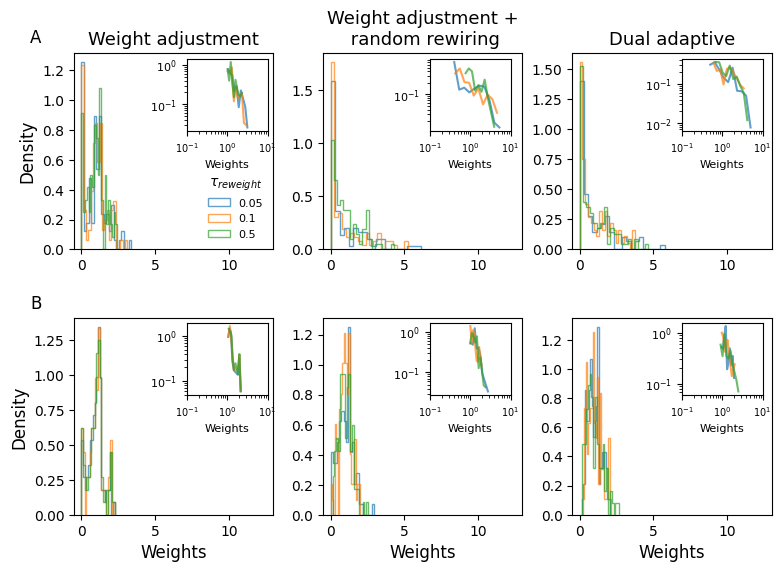

In [6]:
density = 0.01
num_bins = 10 # number of bins on the logscale for the histogram of the upper tail of the weight distribution

plt.rcParams["figure.figsize"] = (9, 6)
fig, ax1 = plt.subplots(2, 3)
for i, cond in enumerate(cond_ls):
    # Adaptive weight adjustment with fixed connectivity
    # weight distribution
    for l, tau in enumerate(tau_ls):
        weights = A_wAdjAlone[cond][tau][density][A_wAdjAlone[cond][tau][density]>0]
        ax1[i, 0].hist(weights, bins=20, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
        ax1[i, 0].tick_params(axis = 'both', labelsize=10)
        ax1[i, 0].set_xlim([-0.5, 13])        

    # right tails in log-log scale           
    left, bottom, width, height = [0.25, 0.75-i*0.44, 0.09, 0.12]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    slope = []
    for l, tau in enumerate(tau_ls):
        res = stats_analysis.PL_MLE(A_wAdjAlone[cond][tau][density], num_bins)    
        
        if res[2] > r2_thresh:
            slope.append(-res[1])
        else:
            slope.append(np.nan)
        weights = A_wAdjAlone[cond][tau][density][A_wAdjAlone[cond][tau][density]>0]
        draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
    ax1_1.set_xlabel('Weights',fontsize=8)
    ax1_1.tick_params(axis = 'both', labelsize=8)
    ax1_1.set_xlim([0.1, 10]) 
    ax1_1.set_xscale('log')
    ax1_1.set_yscale('log')
    ax1_1.xaxis.set_major_locator(LogLocator(base=10, numticks=3))
    ax1_1.xaxis.set_minor_formatter(NullFormatter())
    ax1_1.tick_params(axis='x', labelsize=7)
        
    # Adaptive weight adjustment with random rewiring
    # weight distribution
    for l, tau in enumerate(tau_ls):
        weights = A_wAdjRand[cond][tau][density][A_wAdjRand[cond][tau][density]>0]
        ax1[i, 1].hist(weights, bins=20, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
        ax1[i, 1].tick_params(axis = 'both', labelsize=10)
        ax1[i, 1].set_xlim([-0.5, 13])
    # right tails in log-log scale           
    left, bottom, width, height = [0.52, 0.75-i*0.44, 0.09, 0.12]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    slope = []
    for l, tau in enumerate(tau_ls):
        res = stats_analysis.PL_MLE(A_wAdjRand[cond][tau][density], num_bins) 
        if res[2] > r2_thresh:
            slope.append(-res[1])
        else:
            slope.append(np.nan)
        weights = A_wAdjRand[cond][tau][density][A_wAdjRand[cond][tau][density]>0]
        draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
    ax1_1.set_xlabel('Weights',fontsize=8)
    ax1_1.tick_params(axis = 'both', labelsize=8)
    ax1_1.set_xlim([0.1, 10]) 
    ax1_1.set_xscale('log')
    ax1_1.set_yscale('log')
    ax1_1.xaxis.set_major_locator(LogLocator(base=10, numticks=3))
    ax1_1.xaxis.set_minor_formatter(NullFormatter())
    ax1_1.tick_params(axis='x', labelsize=7)
    
    # Adaptive weight adjustment with adaptive rewiring
    # weight distribution
    for l, tau in enumerate(tau_ls):
        weights = A_dualAdapt[cond][tau][density][A_dualAdapt[cond][tau][density]>0]
        ax1[i, 2].hist(weights, bins=20, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
        ax1[i, 2].tick_params(axis = 'both', labelsize=10)
        ax1[i, 2].set_xlim([-0.5, 13])
    # right tails in log-log scale           
    left, bottom, width, height = [0.80, 0.75-i*0.44, 0.09, 0.12]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    slope = []
    for l, tau in enumerate(tau_ls):
        res = stats_analysis.PL_MLE(A_dualAdapt[cond][tau][density], num_bins) 
        if res[2] > r2_thresh:
            slope.append(-res[1])
        else:
            slope.append(np.nan)
        weights = A_dualAdapt[cond][tau][density][A_dualAdapt[cond][tau][density]>0]
        draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
    ax1_1.set_xlabel('Weights',fontsize=8)
    ax1_1.tick_params(axis = 'both', labelsize=8)
    ax1_1.set_xlim([0.1, 10]) 
    ax1_1.set_xscale('log')
    ax1_1.set_yscale('log')
    ax1_1.xaxis.set_major_locator(LogLocator(base=10, numticks=3))
    ax1_1.xaxis.set_minor_formatter(NullFormatter())
    ax1_1.tick_params(axis='x', labelsize=7)
    
    ax1[i, 0].set_ylabel('Density',fontsize=12)

ax1[0, 0].legend(title = '$\\tau_{reweight}$', frameon=False, loc='lower right', fontsize=8)
ax1[0, 0].set_title('Weight adjustment', fontsize=13)
ax1[0, 1].set_title('Weight adjustment +\n random rewiring', fontsize=13)
ax1[0, 2].set_title('Dual adaptive', fontsize=13)
for s in range(3):
    ax1[1, s].set_xlabel( 'Weights', size=12)
ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
fig.subplots_adjust(hspace = 0.35, wspace = 0.25)
#plt.savefig('../fig/Fig S31.svg', dpi = 300)

# Fig S32: Density = 0.3

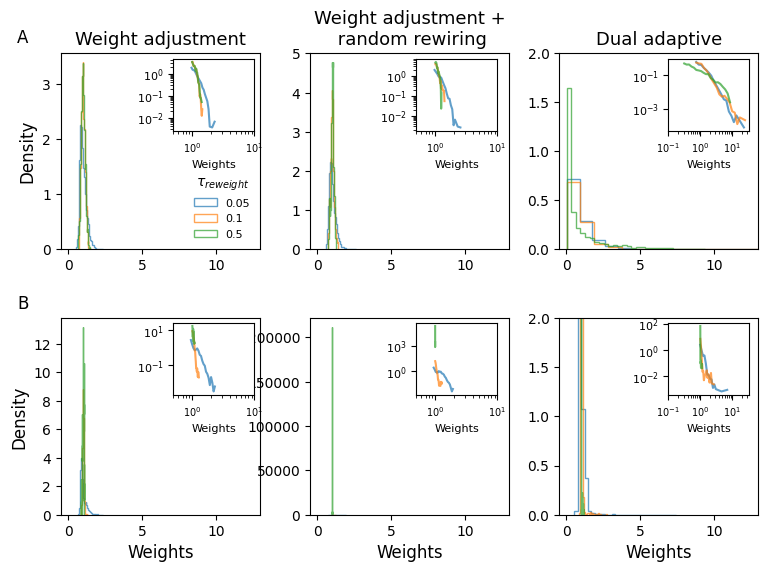

In [7]:
density = 0.3
num_bins = 20 # number of bins on the logscale for the histogram of the upper tail of the weight distribution

plt.rcParams["figure.figsize"] = (9, 6)
fig, ax1 = plt.subplots(2, 3)
for i, cond in enumerate(cond_ls):
    # Adaptive weight adjustment with fixed connectivity
    # weight distribution
    for l, tau in enumerate(tau_ls):
        weights = A_wAdjAlone[cond][tau][density][A_wAdjAlone[cond][tau][density]>0]
        ax1[i, 0].hist(weights, bins=30, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
        ax1[i, 0].tick_params(axis = 'both', labelsize=10)
        ax1[i, 0].set_xlim([-0.5, 13])        
    # right tails in log-log scale           
    left, bottom, width, height = [0.25, 0.75-i*0.44, 0.09, 0.12]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    slope = []
    for l, tau in enumerate(tau_ls):
        res = stats_analysis.PL_MLE(A_wAdjAlone[cond][tau][density], num_bins)     
        if res[2] > r2_thresh:
            slope.append(-res[1])
        else:
            slope.append(np.nan)
        weights = A_wAdjAlone[cond][tau][density][A_wAdjAlone[cond][tau][density]>0]
        draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
    ax1_1.set_xlabel('Weights',fontsize=8)
    ax1_1.tick_params(axis = 'both', labelsize=8)
    ax1_1.set_xscale('log')
    ax1_1.set_yscale('log')
    ax1_1.set_xlim([0.5, 10]) 
    ax1_1.xaxis.set_major_locator(LogLocator(base=10, numticks=3))
    ax1_1.xaxis.set_minor_formatter(NullFormatter())
    ax1_1.tick_params(axis='x', labelsize=7)
        
    # Adaptive weight adjustment with random rewiring
    # weight distribution
    for l, tau in enumerate(tau_ls):
        weights = A_wAdjRand[cond][tau][density][A_wAdjRand[cond][tau][density]>0]
        ax1[i, 1].hist(weights, bins=30, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
        ax1[i, 1].tick_params(axis = 'both', labelsize=10)
        ax1[i, 1].set_xlim([-0.5, 13])
    # right tails in log-log scale           
    left, bottom, width, height = [0.52, 0.75-i*0.44, 0.09, 0.12]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    slope = []
    for l, tau in enumerate(tau_ls):
        res = stats_analysis.PL_MLE(A_wAdjRand[cond][tau][density], num_bins) 
        if res[2] > r2_thresh:
            slope.append(-res[1])
        else:
            slope.append(np.nan)
        weights = A_wAdjRand[cond][tau][density][A_wAdjRand[cond][tau][density]>0]
        draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
    ax1_1.set_xlabel('Weights',fontsize=8)
    ax1_1.tick_params(axis = 'both', labelsize=8)
    ax1_1.set_xlim([0.5, 10]) 
    ax1_1.set_xscale('log')
    ax1_1.set_yscale('log')
    ax1_1.xaxis.set_major_locator(LogLocator(base=10, numticks=3))
    ax1_1.xaxis.set_minor_formatter(NullFormatter())
    ax1_1.tick_params(axis='x', labelsize=7)

    # Adaptive weight adjustment with adaptive rewiring
    # weight distribution
    for l, tau in enumerate(tau_ls):
        weights = A_dualAdapt[cond][tau][density][A_dualAdapt[cond][tau][density]>0]
        ax1[i, 2].hist(weights, bins=30, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
        ax1[i, 2].tick_params(axis = 'both', labelsize=10)
        ax1[i, 2].set_xlim([-0.5, 13])                
        ax1[i, 2].set_ylim([0, 2])
    # right tails in log-log scale           
    left, bottom, width, height = [0.80, 0.75-i*0.44, 0.09, 0.12]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    slope = []
    for l, tau in enumerate(tau_ls):
        res = stats_analysis.PL_MLE(A_dualAdapt[cond][tau][density], num_bins) 
        if res[2] > r2_thresh:
            slope.append(-res[1])
        else:
            slope.append(np.nan)
        weights = A_dualAdapt[cond][tau][density][A_dualAdapt[cond][tau][density]>0]
        draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
    ax1_1.set_xlabel('Weights',fontsize=8)
    ax1_1.tick_params(axis = 'both', labelsize=8)
    ax1_1.set_xlim([1e-1, 35]) 
    
    ax1_1.set_xscale('log')
    ax1_1.set_yscale('log')
    ax1_1.xaxis.set_major_locator(LogLocator(base=10, numticks=3))
    ax1_1.xaxis.set_minor_formatter(NullFormatter())
    ax1_1.tick_params(axis='x', labelsize=7)
    
    ax1[i, 0].set_ylabel('Density',fontsize=12)

ax1[0, 0].legend(title = '$\\tau_{reweight}$', frameon=False, loc='lower right', fontsize=8)
ax1[0, 0].set_title('Weight adjustment', fontsize=13)
ax1[0, 1].set_title('Weight adjustment +\n random rewiring', fontsize=13)
ax1[0, 2].set_title('Dual adaptive', fontsize=13)
for s in range(3):
    ax1[1, s].set_xlabel( 'Weights', size=12)
ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
fig.subplots_adjust(hspace = 0.35, wspace = 0.25)
#plt.savefig('../fig/Fig S32.svg', dpi = 300)